# 07 — Final Model Comparison

This notebook consolidates the **saved metrics** from the final reproducible runs of:

- Isolation Forest
- One-Class SVM (without absolute `step`)
- Autoencoder

No model is retrained here.

The objective is to compare ranking quality and operational behavior under two thresholding strategies:

1. **Max F1** — selective operating point
2. **Recall >= 80%** — high-recall operating point

All conclusions in this notebook are based on artifacts saved by the model notebooks.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Paths

In [2]:
PROCESSED_PATH = Path("../data/processed")
RESULTS_PATH = Path("../results")
METRICS_PATH = RESULTS_PATH / "metrics"

METRICS_PATH.mkdir(parents=True, exist_ok=True)


## Load final ranking metrics

In [3]:
ranking_files = {
    "Isolation Forest": METRICS_PATH / "isolation_forest_ranking_metrics.csv",
    "One-Class SVM": METRICS_PATH / "ocsvm_ranking_metrics.csv",
    "Autoencoder": METRICS_PATH / "autoencoder_ranking_metrics.csv"
}

for model_name, path in ranking_files.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing ranking metrics for {model_name}: {path}"
        )

ranking_results = pd.concat(
    [
        pd.read_csv(path)
        for path in ranking_files.values()
    ],
    ignore_index=True
)

ranking_results


,Model,Validation ROC-AUC,Validation PR-AUC,Test ROC-AUC,Test PR-AUC
0,Isolation Forest,0.965402,0.211203,0.967232,0.210194
1,One-Class SVM,0.924852,0.447337,0.925478,0.437009
2,Autoencoder,0.965819,0.180104,0.966067,0.175239


Expected final test references:

| Model | Test ROC-AUC | Test PR-AUC |
|---|---:|---:|
| Isolation Forest | 0.9672 | 0.2102 |
| One-Class SVM | 0.9255 | 0.4370 |
| Autoencoder | 0.9661 | 0.1752 |


## Ranking comparison

In [4]:
ranking_display = ranking_results[
    [
        "Model",
        "Validation ROC-AUC",
        "Validation PR-AUC",
        "Test ROC-AUC",
        "Test PR-AUC"
    ]
].copy()

ranking_display.round(4)


,Model,Validation ROC-AUC,Validation PR-AUC,Test ROC-AUC,Test PR-AUC
0,Isolation Forest,0.9654,0.2112,0.9672,0.2102
1,One-Class SVM,0.9249,0.4473,0.9255,0.4370
2,Autoencoder,0.9658,0.1801,0.9661,0.1752


In [5]:
best_roc_model = ranking_results.loc[
    ranking_results["Test ROC-AUC"].idxmax(),
    "Model"
]

best_pr_model = ranking_results.loc[
    ranking_results["Test PR-AUC"].idxmax(),
    "Model"
]

print("Best Test ROC-AUC:", best_roc_model)
print("Best Test PR-AUC :", best_pr_model)


Best Test ROC-AUC: Isolation Forest
Best Test PR-AUC : One-Class SVM


## Test ROC-AUC

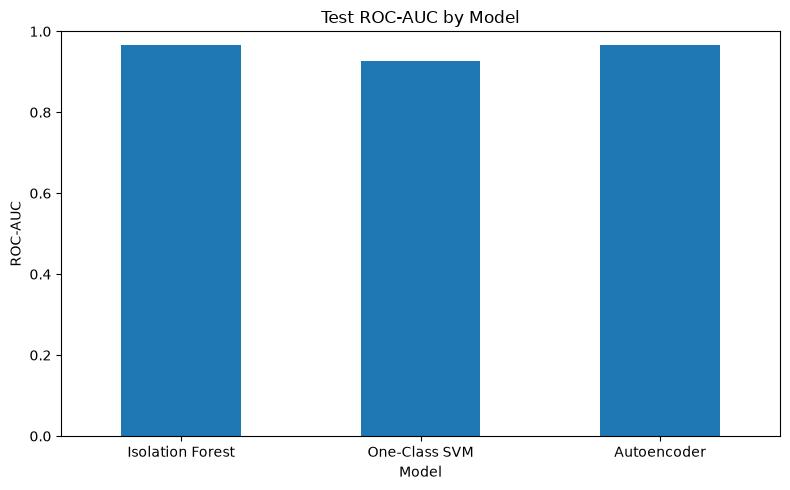

In [6]:
plot_data = ranking_results.set_index("Model")[
    "Test ROC-AUC"
]

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

ax.set_ylim(0, 1)
ax.set_ylabel("ROC-AUC")
ax.set_title("Test ROC-AUC by Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Test PR-AUC

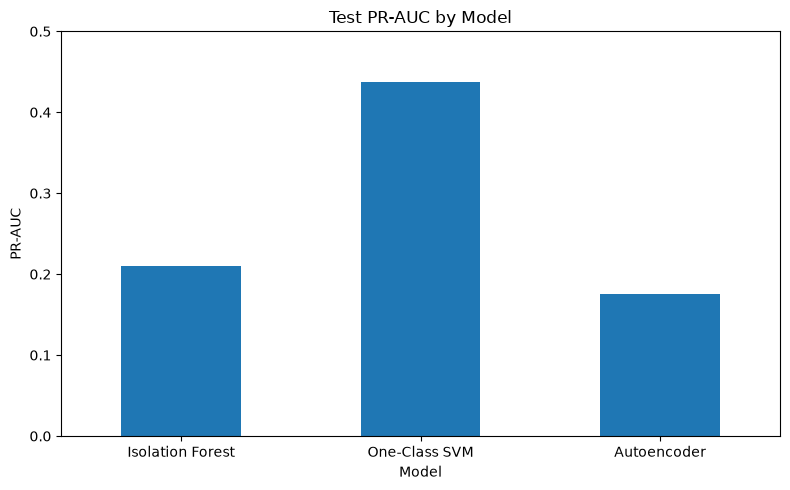

In [7]:
plot_data = ranking_results.set_index("Model")[
    "Test PR-AUC"
]

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

ax.set_ylim(0, max(0.5, plot_data.max() * 1.1))
ax.set_ylabel("PR-AUC")
ax.set_title("Test PR-AUC by Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Ranking interpretation

- **Isolation Forest** and the **Autoencoder** provide the strongest global ranking according to ROC-AUC.
- **One-Class SVM** clearly dominates PR-AUC, which is especially important in this highly imbalanced fraud-detection problem.
- The difference between ROC-AUC and PR-AUC illustrates why a single metric is not sufficient for model selection.


## Load operational metrics

In [8]:
operational_files = {
    "Isolation Forest": METRICS_PATH / "isolation_forest_operational_metrics.csv",
    "One-Class SVM": METRICS_PATH / "ocsvm_operational_metrics.csv",
    "Autoencoder": METRICS_PATH / "autoencoder_operational_metrics.csv"
}

for model_name, path in operational_files.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing operational metrics for {model_name}: {path}"
        )

operational_results = []

for model_name, path in operational_files.items():
    df = pd.read_csv(path).copy()
    df["Model"] = model_name
    operational_results.append(df)

operational_results = pd.concat(
    operational_results,
    ignore_index=True
)

# Normalize naming in case a notebook used "High Recall"
operational_results["Strategy"] = operational_results[
    "Strategy"
].replace({
    "High Recall": "Recall >= 80%"
})

operational_results = operational_results[
    [
        "Model",
        "Strategy",
        "Precision",
        "Recall",
        "F1",
        "False Positive Rate",
        "Alert Rate"
    ]
]

operational_results


,Model,Strategy,Precision,Recall,F1,False Positive Rate,Alert Rate
0,Isolation Forest,Max F1,0.211494,0.460000,0.289764,0.018691,0.023449
1,Isolation Forest,Recall >= 80%,0.133999,0.815833,0.230190,0.057463,0.065639
2,One-Class SVM,Max F1,0.572500,0.381667,0.458000,0.003106,0.007187
3,One-Class SVM,Recall >= 80%,0.106891,0.795000,0.188444,0.072394,0.080184
4,Autoencoder,Max F1,0.299396,0.289167,0.294192,0.007375,0.010413
5,Autoencoder,Recall >= 80%,0.131844,0.939167,0.231227,0.067399,0.076797


## Readable percentage table

In [9]:
display_results = operational_results.copy()

metric_columns = [
    "Precision",
    "Recall",
    "F1",
    "False Positive Rate",
    "Alert Rate"
]

for col in metric_columns:
    display_results[col] = (
        display_results[col] * 100
    ).round(2)

display_results


,Model,Strategy,Precision,Recall,F1,False Positive Rate,Alert Rate
0,Isolation Forest,Max F1,21.15,46.00,28.98,1.87,2.34
1,Isolation Forest,Recall >= 80%,13.40,81.58,23.02,5.75,6.56
2,One-Class SVM,Max F1,57.25,38.17,45.80,0.31,0.72
3,One-Class SVM,Recall >= 80%,10.69,79.50,18.84,7.24,8.02
4,Autoencoder,Max F1,29.94,28.92,29.42,0.74,1.04
5,Autoencoder,Recall >= 80%,13.18,93.92,23.12,6.74,7.68


Expected final references:

### Max F1

| Model | Precision | Recall | F1 | FPR | Alert Rate |
|---|---:|---:|---:|---:|---:|
| Isolation Forest | 21.15% | 46.00% | 28.98% | 1.87% | 2.34% |
| One-Class SVM | 57.25% | 38.17% | 45.80% | 0.31% | 0.72% |
| Autoencoder | 29.94% | 28.92% | 29.42% | 0.74% | 1.04% |

### Recall >= 80%

| Model | Precision | Recall | F1 | FPR | Alert Rate |
|---|---:|---:|---:|---:|---:|
| Isolation Forest | 13.40% | 81.58% | 23.02% | 5.75% | 6.56% |
| One-Class SVM | 10.69% | 79.50% | 18.84% | 7.24% | 8.02% |
| Autoencoder | 13.18% | 93.92% | 23.12% | 6.74% | 7.68% |


## Max-F1 comparison

In [10]:
max_f1_results = operational_results[
    operational_results["Strategy"] == "Max F1"
].copy()

max_f1_results


,Model,Strategy,Precision,Recall,F1,False Positive Rate,Alert Rate
0,Isolation Forest,Max F1,0.211494,0.460000,0.289764,0.018691,0.023449
2,One-Class SVM,Max F1,0.572500,0.381667,0.458000,0.003106,0.007187
4,Autoencoder,Max F1,0.299396,0.289167,0.294192,0.007375,0.010413


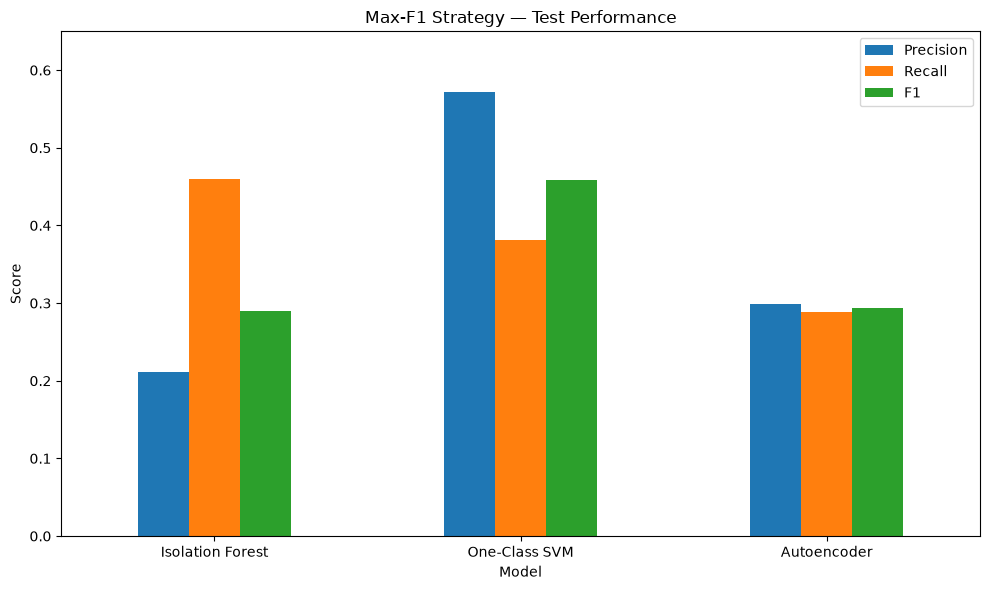

In [11]:
plot_df = max_f1_results.set_index("Model")[
    ["Precision", "Recall", "F1"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("Score")
ax.set_ylim(0, 0.65)
ax.set_title("Max-F1 Strategy — Test Performance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [12]:
max_f1_summary = max_f1_results.set_index("Model")

print(
    "Highest precision:",
    max_f1_summary["Precision"].idxmax()
)

print(
    "Highest recall:",
    max_f1_summary["Recall"].idxmax()
)

print(
    "Highest F1:",
    max_f1_summary["F1"].idxmax()
)

print(
    "Lowest false-positive rate:",
    max_f1_summary["False Positive Rate"].idxmin()
)

print(
    "Lowest alert rate:",
    max_f1_summary["Alert Rate"].idxmin()
)


Highest precision: One-Class SVM
Highest recall: Isolation Forest
Highest F1: One-Class SVM
Lowest false-positive rate: One-Class SVM
Lowest alert rate: One-Class SVM


### Max-F1 conclusion

**One-Class SVM** is the strongest model for high-confidence investigations:

- highest precision
- highest F1
- lowest false-positive rate
- lowest alert rate

It is therefore the best choice when investigation capacity is limited and each alert should be as reliable as possible.


## High-recall comparison

In [13]:
high_recall_results = operational_results[
    operational_results["Strategy"] == "Recall >= 80%"
].copy()

high_recall_results


,Model,Strategy,Precision,Recall,F1,False Positive Rate,Alert Rate
1,Isolation Forest,Recall >= 80%,0.133999,0.815833,0.230190,0.057463,0.065639
3,One-Class SVM,Recall >= 80%,0.106891,0.795000,0.188444,0.072394,0.080184
5,Autoencoder,Recall >= 80%,0.131844,0.939167,0.231227,0.067399,0.076797


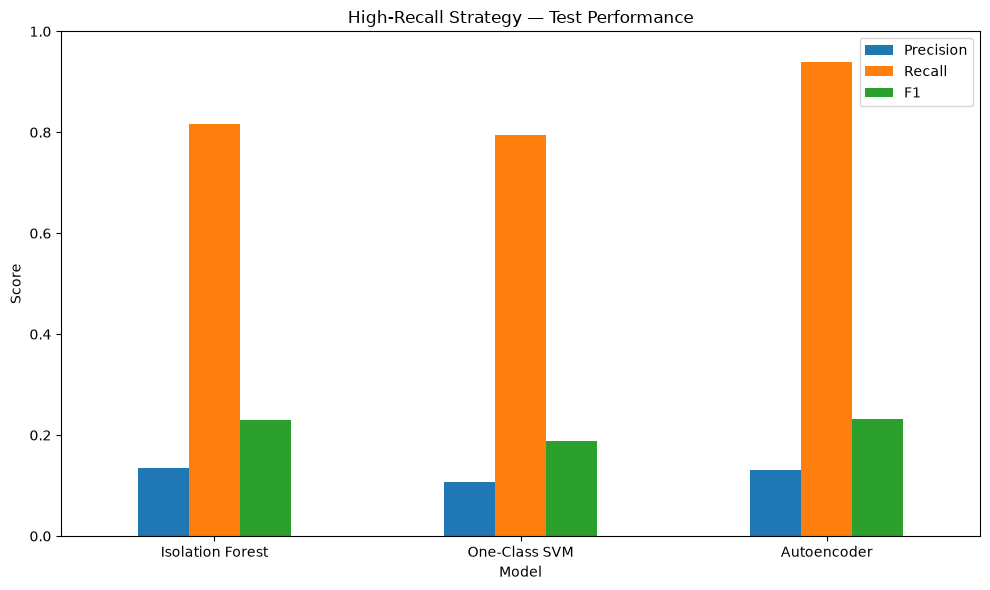

In [14]:
plot_df = high_recall_results.set_index("Model")[
    ["Precision", "Recall", "F1"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("High-Recall Strategy — Test Performance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Operational cost in high-recall mode

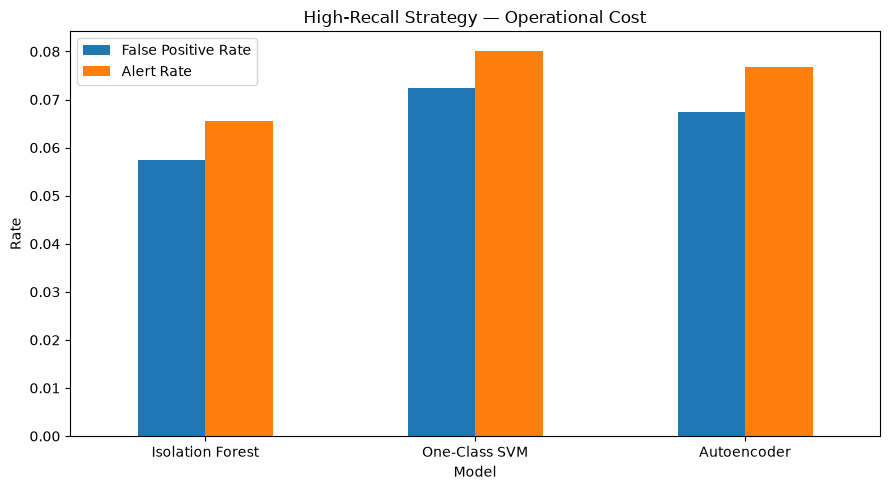

In [15]:
plot_df = high_recall_results.set_index("Model")[
    ["False Positive Rate", "Alert Rate"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_ylabel("Rate")
ax.set_title("High-Recall Strategy — Operational Cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [16]:
high_recall_summary = high_recall_results.set_index("Model")

print(
    "Highest recall:",
    high_recall_summary["Recall"].idxmax()
)

print(
    "Highest precision:",
    high_recall_summary["Precision"].idxmax()
)

print(
    "Lowest false-positive rate:",
    high_recall_summary["False Positive Rate"].idxmin()
)

print(
    "Lowest alert rate:",
    high_recall_summary["Alert Rate"].idxmin()
)


Highest recall: Autoencoder
Highest precision: Isolation Forest
Lowest false-positive rate: Isolation Forest
Lowest alert rate: Isolation Forest


### High-recall conclusion

The models serve different objectives:

- **Autoencoder** maximizes fraud coverage and reaches the highest recall.
- **Isolation Forest** offers a better balance between recall, false positives and alert volume.
- **One-Class SVM** is less attractive in this operating mode because it produces more alerts while recovering fewer frauds than the Autoencoder.


## Approximate number of detected and missed frauds

In [17]:
y_test = np.load(
    PROCESSED_PATH / "y_test.npy"
)

TOTAL_TEST = len(y_test)
TOTAL_FRAUDS = int(y_test.sum())
TOTAL_LEGITIMATE = TOTAL_TEST - TOTAL_FRAUDS

print("Test transactions :", TOTAL_TEST)
print("Frauds            :", TOTAL_FRAUDS)
print("Legitimate        :", TOTAL_LEGITIMATE)


Test transactions : 111306
Frauds            : 1200
Legitimate        : 110106


In [18]:
count_results = operational_results.copy()

count_results["Frauds Detected"] = (
    count_results["Recall"]
    * TOTAL_FRAUDS
).round().astype(int)

count_results["Frauds Missed"] = (
    TOTAL_FRAUDS
    - count_results["Frauds Detected"]
)

count_results["False Alerts"] = (
    count_results["False Positive Rate"]
    * TOTAL_LEGITIMATE
).round().astype(int)

count_results[
    [
        "Model",
        "Strategy",
        "Frauds Detected",
        "Frauds Missed",
        "False Alerts"
    ]
]


,Model,Strategy,Frauds Detected,Frauds Missed,False Alerts
0,Isolation Forest,Max F1,552,648,2058
1,Isolation Forest,Recall >= 80%,979,221,6327
2,One-Class SVM,Max F1,458,742,342
3,One-Class SVM,Recall >= 80%,954,246,7971
4,Autoencoder,Max F1,347,853,812
5,Autoencoder,Recall >= 80%,1127,73,7421


With the final runs, the key operational examples are approximately:

- **One-Class SVM / Max F1**: 458 frauds detected with only 342 false alerts
- **Isolation Forest / High Recall**: 979 frauds detected
- **Autoencoder / High Recall**: 1,127 frauds detected, only 73 missed


## Stability between validation and test

In [19]:
stability = ranking_results[
    [
        "Model",
        "Validation ROC-AUC",
        "Test ROC-AUC",
        "Validation PR-AUC",
        "Test PR-AUC"
    ]
].copy()

stability["ROC-AUC Gap"] = (
    stability["Test ROC-AUC"]
    - stability["Validation ROC-AUC"]
)

stability["PR-AUC Gap"] = (
    stability["Test PR-AUC"]
    - stability["Validation PR-AUC"]
)

stability.round(4)


,Model,Validation ROC-AUC,Test ROC-AUC,Validation PR-AUC,Test PR-AUC,ROC-AUC Gap,PR-AUC Gap
0,Isolation Forest,0.9654,0.9672,0.2112,0.2102,0.0018,-0.0010
1,One-Class SVM,0.9249,0.9255,0.4473,0.4370,0.0006,-0.0103
2,Autoencoder,0.9658,0.9661,0.1801,0.1752,0.0002,-0.0049


The small validation-to-test gaps are a positive result: the final model configurations generalize consistently across the temporal split.

A particularly important finding was the One-Class SVM ablation:

- using absolute `step` caused severe score drift
- removing `step` stabilized the validation/test score distributions

This is a concrete example of **feature-induced distribution shift**.


## Final model-selection table

In [20]:
model_selection = pd.DataFrame([
    {
        "Operational Goal": "High-confidence investigations",
        "Recommended Model": "One-Class SVM",
        "Reason": (
            "Highest precision and F1 with the lowest "
            "false-positive and alert rates."
        )
    },
    {
        "Operational Goal": "Balanced high-recall screening",
        "Recommended Model": "Isolation Forest",
        "Reason": (
            "Strong recall with lower operational cost "
            "than the maximum-coverage Autoencoder mode."
        )
    },
    {
        "Operational Goal": "Maximum fraud coverage",
        "Recommended Model": "Autoencoder",
        "Reason": (
            "Highest recall; detects about 94% of fraud "
            "in the final test run."
        )
    }
])

model_selection


,Operational Goal,Recommended Model,Reason
0,High-confidence investigations,One-Class SVM,Highest precision and F1 with the lowest false...
1,Balanced high-recall screening,Isolation Forest,Strong recall with lower operational cost than...
2,Maximum fraud coverage,Autoencoder,Highest recall; detects about 94% of fraud in ...


## Final conclusions

No single anomaly detector dominates across all objectives.

### One-Class SVM
Best suited for **high-confidence alerts**.  
Its final Max-F1 test operating point reaches roughly **57% precision** while flagging less than **1% of transactions**.

### Isolation Forest
The strongest **robust baseline** and a good high-recall compromise.  
It combines excellent ROC-AUC, simple CPU-friendly training and a more controlled alert volume than the maximum-recall Autoencoder operating point.

### Autoencoder
Best suited for **maximum fraud coverage**.  
Its high-recall threshold detects roughly **94% of test frauds**, at the cost of more false positives and a larger alert queue.

### Methodological lesson
Absolute time can be useful for **temporal splitting** without necessarily being useful as a **model input feature**.  
For the RBF One-Class SVM, including `step` created a strong artificial score drift. Removing it restored stable generalization.

The next phase of the project is to move from:

**anomaly score → explanation → investigation context → LLM-generated investigation report**


## Save consolidated comparison artifacts

In [21]:
ranking_results.to_csv(
    METRICS_PATH / "model_ranking_comparison.csv",
    index=False
)

operational_results.to_csv(
    METRICS_PATH / "model_operational_comparison.csv",
    index=False
)

model_selection.to_csv(
    METRICS_PATH / "model_selection.csv",
    index=False
)

count_results[
    [
        "Model",
        "Strategy",
        "Frauds Detected",
        "Frauds Missed",
        "False Alerts"
    ]
].to_csv(
    METRICS_PATH / "model_alert_counts.csv",
    index=False
)

print("Comparison artifacts saved.")


Comparison artifacts saved.


In [22]:
print("Saved:")
print(METRICS_PATH / "model_ranking_comparison.csv")
print(METRICS_PATH / "model_operational_comparison.csv")
print(METRICS_PATH / "model_selection.csv")
print(METRICS_PATH / "model_alert_counts.csv")


Saved:
..\results\metrics\model_ranking_comparison.csv
..\results\metrics\model_operational_comparison.csv
..\results\metrics\model_selection.csv
..\results\metrics\model_alert_counts.csv
